In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
import missingno as msno

## Step 1: Load the Dataset

In [2]:
df = pd.read_csv('telecom_customer_churn/telecom_customer_churn.csv')
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [3]:
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Shape: (7043, 38)
Rows: 7043, Columns: 38


In [4]:
print(df.dtypes)

Customer ID                           object
Gender                                object
Age                                    int64
Married                               object
Number of Dependents                   int64
City                                  object
Zip Code                               int64
Latitude                             float64
Longitude                            float64
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                 object
Phone Service                         object
Avg Monthly Long Distance Charges    float64
Multiple Lines                        object
Internet Service                      object
Internet Type                         object
Avg Monthly GB Download              float64
Online Security                       object
Online Backup                         object
Device Protection Plan                object
Premium Tech Support                  object
Streaming 

## Step 2: Initial Overview

### Column Classification

**Identifier:** CustomerID

**Demographics:** Gender, Age, Married, Number of Dependents

**Location:** City, Zip Code, Latitude, Longitude

**Account Info:** Tenure in Months, Number of Referrals, Offer, Contract, Paperless Billing, Payment Method

**Phone Services:** Phone Service, Avg Monthly Long Distance Charges, Multiple Lines

**Internet Services:** Internet Service, Internet Type, Avg Monthly GB Download, Online Security, Online Backup, Device Protection Plan, Premium Tech Support, Streaming TV, Streaming Movies, Streaming Music, Unlimited Data

**Financials:** Monthly Charge, Total Charges, Total Refunds, Total Extra Data Charges, Total Long Distance Charges, Total Revenue

**Churn Labels:** Customer Status, Churn Category, Churn Reason

## Step 3: Data Inconsistencies

### Exploring all columns for inconsistencies

#### 1. Checking all categorical columns
- Using value_counts() on all categorical columns such as Gender, Married, Offer, Contract, Payment Method, Internet Type, Customer Status, Churn Category, and all Yes/No service columns to spot typos or unexpected values.

#### 2. Checking all numerical columns
- Using describe() on Age, Tenure in Months, Monthly Charge, Total Charges,
  Total Revenue and other financial columns to spot unrealistic values such as
  negative charges or out-of-range ages.

- Also verifying the Total Revenue formula:
  Total Revenue = Total Charges - Total Refunds + Total Extra Data Charges + Total Long Distance Charges

#### 3. Checking domain-specific rules
- If Phone Service is No, then Avg Monthly Long Distance Charges and Multiple Lines should be 0 / No respectively.
- If Internet Service is No, all internet add-on columns should be No and internet-type columns None.
- Churn Category and Churn Reason should only be populated for Churned customers.

In [5]:
print(df['Gender'].value_counts())

Gender
Male      3555
Female    3488
Name: count, dtype: int64


In [6]:
print(df['Married'].value_counts())

Married
No     3641
Yes    3402
Name: count, dtype: int64


In [7]:
print(df['Offer'].value_counts())

Offer
Offer B    824
Offer E    805
Offer D    602
Offer A    520
Offer C    415
Name: count, dtype: int64


In [8]:
print(df['Contract'].value_counts())

Contract
Month-to-Month    3610
Two Year          1883
One Year          1550
Name: count, dtype: int64


In [9]:
print(df['Payment Method'].value_counts())

Payment Method
Bank Withdrawal    3909
Credit Card        2749
Mailed Check        385
Name: count, dtype: int64


In [10]:
print(df['Internet Type'].value_counts(dropna=False))

Internet Type
Fiber Optic    3035
DSL            1652
NaN            1526
Cable           830
Name: count, dtype: int64


In [11]:
print(df['Customer Status'].value_counts())

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64


In [12]:
print(df['Churn Category'].value_counts(dropna=False))

Churn Category
NaN                5174
Competitor          841
Dissatisfaction     321
Attitude            314
Price               211
Other               182
Name: count, dtype: int64


In [13]:
print(df['Churn Reason'].value_counts(dropna=False).head(20))

Churn Reason
NaN                                          5174
Competitor had better devices                 313
Competitor made better offer                  311
Attitude of support person                    220
Don't know                                    130
Competitor offered more data                  117
Competitor offered higher download speeds     100
Attitude of service provider                   94
Price too high                                 78
Product dissatisfaction                        77
Network reliability                            72
Long distance charges                          64
Service dissatisfaction                        63
Moved                                          46
Extra data charges                             39
Limited range of services                      37
Poor expertise of online support               31
Lack of affordable download/upload speed       30
Lack of self-service on Website                29
Poor expertise of phone support      

In [14]:
yes_no_cols = [
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data', 'Paperless Billing'
]

for col in yes_no_cols:
    print(f"{col}:")
    print(df[col].value_counts())
    print()

Phone Service:
Phone Service
Yes    6361
No      682
Name: count, dtype: int64

Multiple Lines:
Multiple Lines
No     3390
Yes    2971
Name: count, dtype: int64

Internet Service:
Internet Service
Yes    5517
No     1526
Name: count, dtype: int64

Online Security:
Online Security
No     3498
Yes    2019
Name: count, dtype: int64

Online Backup:
Online Backup
No     3088
Yes    2429
Name: count, dtype: int64

Device Protection Plan:
Device Protection Plan
No     3095
Yes    2422
Name: count, dtype: int64

Premium Tech Support:
Premium Tech Support
No     3473
Yes    2044
Name: count, dtype: int64

Streaming TV:
Streaming TV
No     2810
Yes    2707
Name: count, dtype: int64

Streaming Movies:
Streaming Movies
No     2785
Yes    2732
Name: count, dtype: int64

Streaming Music:
Streaming Music
No     3029
Yes    2488
Name: count, dtype: int64

Unlimited Data:
Unlimited Data
Yes    4745
No      772
Name: count, dtype: int64

Paperless Billing:
Paperless Billing
Yes    4171
No     2872
Name:

In [15]:
numerical_cols = [
    'Age', 'Number of Dependents', 'Number of Referrals',
    'Tenure in Months', 'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges',
    'Total Refunds', 'Total Extra Data Charges',
    'Total Long Distance Charges', 'Total Revenue'
]

df[numerical_cols].describe().round(2)

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.00,7043.00,7043.00,7043.00,6361.00,5517.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,46.51,0.47,1.95,32.39,25.42,26.19,63.60,2280.38,1.96,6.86,749.10,3034.38
std,16.75,0.96,3.00,24.54,14.20,19.59,31.20,2266.22,7.90,25.10,846.66,2865.20
min,19.00,0.00,0.00,1.00,1.01,2.00,-10.00,18.80,0.00,0.00,0.00,21.36
25%,32.00,0.00,0.00,9.00,13.05,13.00,30.40,400.15,0.00,0.00,70.54,605.61
50%,46.00,0.00,0.00,29.00,25.69,21.00,70.05,1394.55,0.00,0.00,401.44,2108.64
75%,60.00,0.00,3.00,55.00,37.68,30.00,89.75,3786.60,0.00,0.00,1191.10,4801.15
max,80.00,9.00,11.00,72.00,49.99,85.00,118.75,8684.80,49.79,150.00,3564.72,11979.34


In [16]:
print("Negative values in financial columns:")
financial_cols = ['Monthly Charge', 'Total Charges', 'Total Revenue']
for col in financial_cols:
    neg_count = (df[col] < 0).sum()
    print(f"  {col}: {neg_count} negative values")

Negative values in financial columns:
  Monthly Charge: 120 negative values
  Total Charges: 0 negative values
  Total Revenue: 0 negative values


In [17]:
print("Age range check:")
print(f"  Min Age: {df['Age'].min()}")
print(f"  Max Age: {df['Age'].max()}")

Age range check:
  Min Age: 19
  Max Age: 80


### Verifying Total Revenue Formula

According to the dataset documentation, Total Revenue is calculated as:
Total Charges - Total Refunds + Total Extra Data Charges + Total Long Distance Charges

In [18]:
df['computed_revenue'] = (
    df['Total Charges']
    - df['Total Refunds']
    + df['Total Extra Data Charges']
    + df['Total Long Distance Charges']
)

revenue_diff = (df['computed_revenue'] - df['Total Revenue']).abs()
print(f"Max discrepancy in Total Revenue: {revenue_diff.max():.4f}")
print(f"Rows with discrepancy > 0.01: {(revenue_diff > 0.01).sum()}")

df.drop(columns=['computed_revenue'], inplace=True)

Max discrepancy in Total Revenue: 0.0000
Rows with discrepancy > 0.01: 0


### Domain Rule Validations

In [19]:
no_phone = df[df['Phone Service'] == 'No']
print("Customers with no phone service but non-zero Long Distance Charges:")
print((no_phone['Avg Monthly Long Distance Charges'] != 0).sum())

print("\nCustomers with no phone service but Multiple Lines = Yes:")
print((no_phone['Multiple Lines'] == 'Yes').sum())

Customers with no phone service but non-zero Long Distance Charges:
682

Customers with no phone service but Multiple Lines = Yes:
0


In [20]:
no_internet = df[df['Internet Service'] == 'No']
internet_add_ons = [
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data'
]
print("Customers with no Internet Service but add-on services set to Yes:")
for col in internet_add_ons:
    count = (no_internet[col] == 'Yes').sum()
    if count > 0:
        print(f"  {col}: {count} violations")
print("\nInternet Type for non-internet customers (should be None):")
print(no_internet['Internet Type'].value_counts(dropna=False))

Customers with no Internet Service but add-on services set to Yes:

Internet Type for non-internet customers (should be None):
Internet Type
NaN    1526
Name: count, dtype: int64


In [21]:
non_churned = df[df['Customer Status'] != 'Churned']
print("Non-churned customers with Churn Category populated:")
print(non_churned['Churn Category'].notna().sum())

print("\nChurned customers with missing Churn Category:")
churned = df[df['Customer Status'] == 'Churned']
print(churned['Churn Category'].isna().sum())

Non-churned customers with Churn Category populated:
0

Churned customers with missing Churn Category:
0


After checking all columns:

1. All categorical columns have clean, expected values with no typos or unexpected categories.
2. Monthly Charge is found to have negative values
3. Age values are within a realistic adult range.
4. Total Revenue matches the documented formula with negligible floating-point differences.
5. Phone service add-ons are NOT 0/No for non-phone customers. Internet add-ons are No for non-internet customers.
6. Churn Category and Churn Reason are only populated for churned customers.

## Step 4: Missing Values Analysis

In [22]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                                   Missing Count  Missing %
Offer                                       3877      55.05
Avg Monthly Long Distance Charges            682       9.68
Multiple Lines                               682       9.68
Internet Type                               1526      21.67
Avg Monthly GB Download                     1526      21.67
Online Security                             1526      21.67
Online Backup                               1526      21.67
Device Protection Plan                      1526      21.67
Premium Tech Support                        1526      21.67
Streaming TV                                1526      21.67
Streaming Movies                            1526      21.67
Streaming Music                             1526      21.67
Unlimited Data                              1526      21.67
Churn Category                              5174      73.46
Churn Reason                                5174      73.46


<Figure size 1000x400 with 0 Axes>

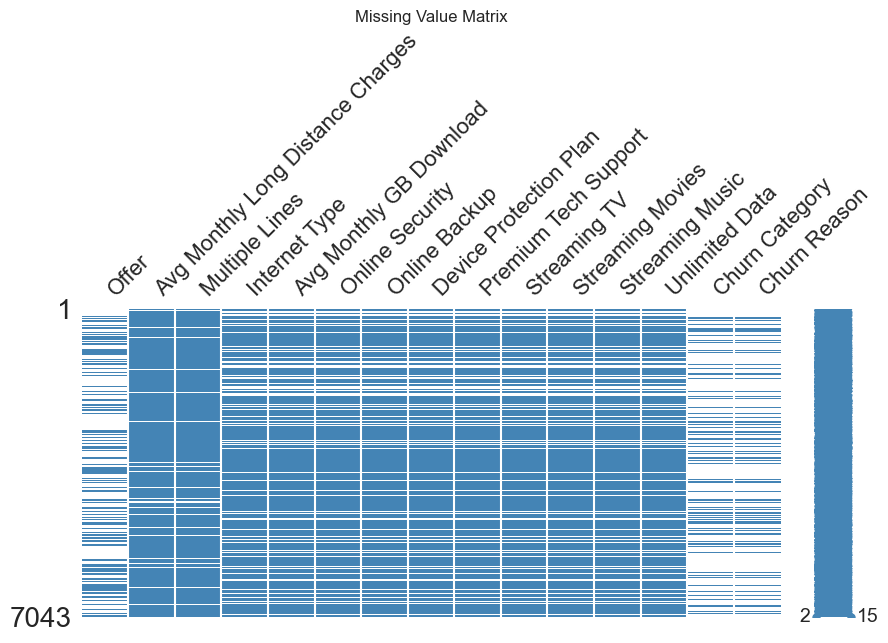

In [23]:
cols_with_missing = missing[missing > 0].index.tolist()

plt.figure(figsize=(10, 4))
msno.matrix(df[cols_with_missing], figsize=(10, 4), color=(0.27, 0.52, 0.71))
plt.title('Missing Value Matrix')
plt.show()

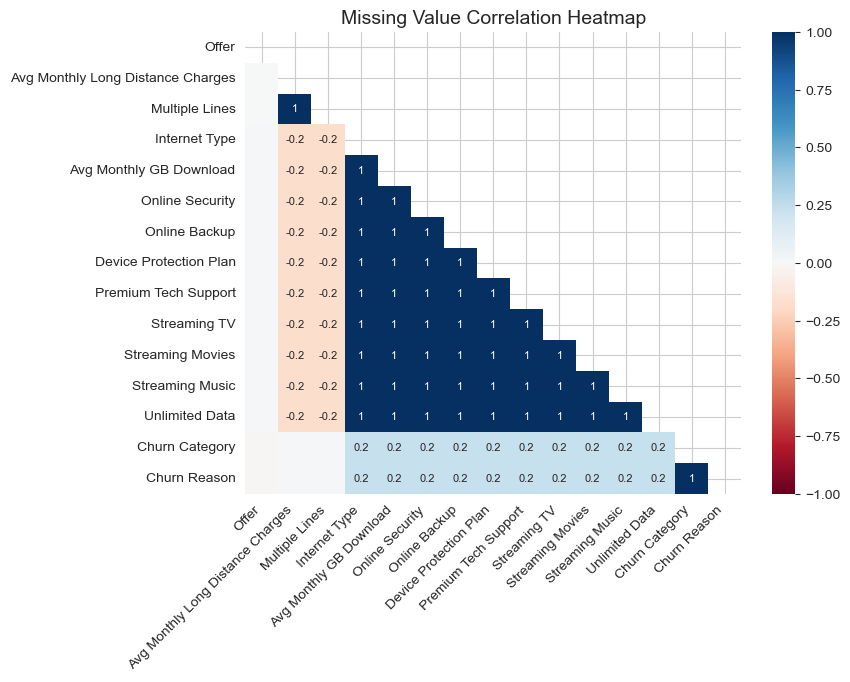

In [24]:
msno.heatmap(df[cols_with_missing], figsize=(8, 6), fontsize=10)
plt.title('Missing Value Correlation Heatmap', fontsize=14)
plt.show()

Based on the visualizations above, the missingness pattern and strategy for each column:

- **Churn Category** and **Churn Reason**: MNAR by design. These fields are intentionally
  blank for customers who did not churn (Stayed or Joined). No imputation required. They
  will be analyzed only within the churned subset.

- **Avg Monthly Long Distance Charges**: If missing values exist, they should correspond
  to customers with no phone service. Will verify and fill with 0 accordingly.

- **Internet Type**: Missing values are expected for customers with no internet service.
  Will fill with 'None' for consistency with the documented expected value.

### Verifying If Missing Values Match Service Conditions 

#### Phone Service

In [25]:
print("Validating internet service conditions...")

# Check if Phone Service = No customers have nulls in expected fields
no_phone = df[df['Phone Service'] == 'No']

# Check Multiple Lines
multiple_lines_null = no_phone['Multiple Lines'].isnull().sum()
print(f"Customers with Phone Service = No: {len(no_phone)}")
print(f"  - Multiple Lines null: {multiple_lines_null} (Expected: {len(no_phone)})")

# Check Avg Monthly Long Distance Charges
ld_charges_null = no_phone['Avg Monthly Long Distance Charges'].isnull().sum()
print(f"  - Avg Monthly Long Distance Charges null: {ld_charges_null} (Expected: {len(no_phone)})")

# Verify all expected nulls are present
if multiple_lines_null == len(no_phone) and ld_charges_null == len(no_phone):
    print("\nVALIDATION PASSED: All Phone Service = No customers have nulls in expected fields")
else:
    print("\nVALIDATION FAILED: Some expected nulls are missing")
    print(f"  - Multiple Lines missing nulls: {len(no_phone) - multiple_lines_null}")
    print(f"  - Long Distance Charges missing nulls: {len(no_phone) - ld_charges_null}")

print("\n")

Validating internet service conditions...
Customers with Phone Service = No: 682
  - Multiple Lines null: 682 (Expected: 682)
  - Avg Monthly Long Distance Charges null: 682 (Expected: 682)

VALIDATION PASSED: All Phone Service = No customers have nulls in expected fields




#### Internet Service

In [26]:
print("Validating internet service conditions...")

no_internet = df[df['Internet Service'] == 'No']
internet_add_ons = [
    'Internet Type', 'Avg Monthly GB Download', 'Online Security', 
    'Online Backup', 'Device Protection Plan', 'Premium Tech Support',
    'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data'
]

print(f"Customers with Internet Service = No: {len(no_internet)}")
for col in internet_add_ons:
    null_count = no_internet[col].isnull().sum()
    print(f"  - {col} null: {null_count} (Expected: {len(no_internet)})")

# Verify all expected nulls are present
all_valid = all(no_internet[col].isnull().sum() == len(no_internet) for col in internet_add_ons)
if all_valid:
    print("\nVALIDATION PASSED: All Internet Service = No customers have nulls in expected fields")
else:
    print("\nVALIDATION FAILED: Some expected nulls are missing")
    for col in internet_add_ons:
        missing = len(no_internet) - no_internet[col].isnull().sum()
        if missing > 0:
            print(f"  - {col}: {missing} customers have values (should be null)")

print("\n")

Validating internet service conditions...
Customers with Internet Service = No: 1526
  - Internet Type null: 1526 (Expected: 1526)
  - Avg Monthly GB Download null: 1526 (Expected: 1526)
  - Online Security null: 1526 (Expected: 1526)
  - Online Backup null: 1526 (Expected: 1526)
  - Device Protection Plan null: 1526 (Expected: 1526)
  - Premium Tech Support null: 1526 (Expected: 1526)
  - Streaming TV null: 1526 (Expected: 1526)
  - Streaming Movies null: 1526 (Expected: 1526)
  - Streaming Music null: 1526 (Expected: 1526)
  - Unlimited Data null: 1526 (Expected: 1526)

VALIDATION PASSED: All Internet Service = No customers have nulls in expected fields




### Apply Transformations

In [50]:
print("Applying transformations...")

# Offer column transformation (no offer)
print("\n  Offer Transformations:")
df['Offer'] = df['Offer'].fillna('None')
nulls_remaining_offer = df['Offer'].isnull().sum()
print(f"  - Offer: {nulls_remaining_offer} nulls remaining")

# Phone service related transformations
print("\nPhone Service Transformations:")
df.loc[df['Phone Service'] == 'No', 'Multiple Lines'] = df.loc[df['Phone Service'] == 'No', 'Multiple Lines'].fillna('No')
df.loc[df['Phone Service'] == 'No', 'Avg Monthly Long Distance Charges'] = df.loc[df['Phone Service'] == 'No', 'Avg Monthly Long Distance Charges'].fillna(0)

# Verify transformations
no_phone_after = df[df['Phone Service'] == 'No']
print(f"  - Multiple Lines: {no_phone_after['Multiple Lines'].isnull().sum()} nulls remaining")
print(f"  - Avg Monthly Long Distance Charges: {no_phone_after['Avg Monthly Long Distance Charges'].isnull().sum()} nulls remaining")

print("\nInternet Service Transformations:")
# Internet service related transformations
df.loc[df['Internet Service'] == 'No', 'Internet Type'] = df.loc[df['Internet Service'] == 'No', 'Internet Type'].fillna('None')
df.loc[df['Internet Service'] == 'No', 'Avg Monthly GB Download'] = df.loc[df['Internet Service'] == 'No', 'Avg Monthly GB Download'].fillna(0)

for col in ['Online Security', 'Online Backup', 'Device Protection Plan', 
            'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 
            'Streaming Music', 'Unlimited Data']:
    df.loc[df['Internet Service'] == 'No', col] = df.loc[df['Internet Service'] == 'No', col].fillna('No')

# Verify transformations
no_internet_after = df[df['Internet Service'] == 'No']
for col in internet_add_ons:
    null_count = no_internet_after[col].isnull().sum()
    print(f"  - {col}: {null_count} nulls remaining")

print("\nTransformation Complete")

Applying transformations...

  Offer Transformations:
  - Offer: 0 nulls remaining

Phone Service Transformations:
  - Multiple Lines: 0 nulls remaining
  - Avg Monthly Long Distance Charges: 0 nulls remaining

Internet Service Transformations:
  - Internet Type: 0 nulls remaining
  - Avg Monthly GB Download: 0 nulls remaining
  - Online Security: 0 nulls remaining
  - Online Backup: 0 nulls remaining
  - Device Protection Plan: 0 nulls remaining
  - Premium Tech Support: 0 nulls remaining
  - Streaming TV: 0 nulls remaining
  - Streaming Movies: 0 nulls remaining
  - Streaming Music: 0 nulls remaining
  - Unlimited Data: 0 nulls remaining

Transformation Complete


### Final Verification Of All Nulls

In [52]:
print("Checking all null values again...")

remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

if len(remaining_nulls) == 0:
    print("\n All service-related nulls have been properly transformed!")
    print("  No remaining null values in the dataset (except in Churn Category and Churn Reason")
else:
    print("\nRemaining null values found:")
    print(remaining_nulls)
    
    # Separate Churn-related vs other nulls
    churn_related = ['Churn Category', 'Churn Reason']
    other_nulls = [col for col in remaining_nulls.index if col not in churn_related]
    
    if other_nulls:
        print(f"\n  Unexpected nulls in: {other_nulls}")
    else:
        print("\n  Only Churn Category and Churn Reason have nulls")

print("\n" + "=" * 60)

Checking all null values again...

Remaining null values found:
Churn Category    5174
Churn Reason      5174
dtype: int64

  Only Churn Category and Churn Reason have nulls



## Step 5: Exploratory Data Analysis

### 5.1 Churn Overview

In [53]:
status_counts = df['Customer Status'].value_counts()
churn_rate = (df['Customer Status'] == 'Churned').mean() * 100

print("Customer Status Distribution:")
print(status_counts)
print(f"\nOverall Churn Rate: {churn_rate:.2f}%")

Customer Status Distribution:
Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

Overall Churn Rate: 26.54%


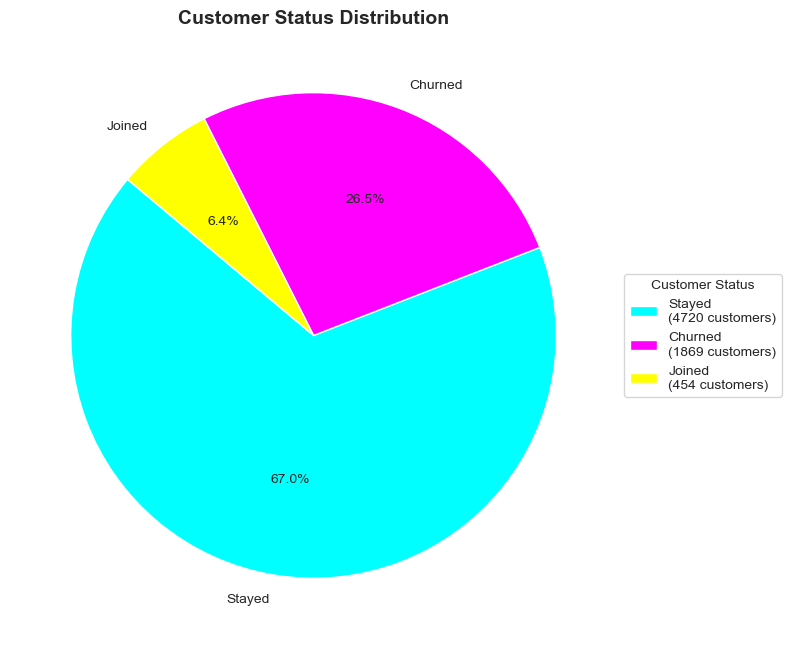

In [54]:
colors = ["#00ffff", "#FF00FF", '#ffff00']

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)

# Add count numbers to labels
labels_with_counts = [f'{label}\n({count} customers)' 
                      for label, count in zip(status_counts.index, status_counts.values)]
plt.legend(wedges, labels_with_counts, title="Customer Status", 
           loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Customer Status Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Descriptive Statistics for Numerical Variables

In [55]:
numerical_cols = [
    'Age', 'Number of Dependents', 'Number of Referrals',
    'Tenure in Months', 'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges',
    'Total Refunds', 'Total Extra Data Charges',
    'Total Long Distance Charges', 'Total Revenue'
]

desc = df[numerical_cols].describe().T
desc['skewness'] = df[numerical_cols].skew().round(4)
desc['kurtosis'] = df[numerical_cols].kurt().round(4)
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Age,7043.0,46.51,16.75,19.00,32.00,46.00,60.00,80.00,0.16,-1.00
Number of Dependents,7043.0,0.47,0.96,0.00,0.00,0.00,0.00,9.00,2.11,4.45
Number of Referrals,7043.0,1.95,3.00,0.00,0.00,0.00,3.00,11.00,1.45,0.72
Tenure in Months,7043.0,32.39,24.54,1.00,9.00,29.00,55.00,72.00,0.24,-1.39
Avg Monthly Long Distance Charges,7043.0,22.96,15.45,0.00,9.21,22.89,36.39,49.99,0.05,-1.25
Avg Monthly GB Download,7043.0,20.52,20.42,0.00,3.00,17.00,27.00,85.00,1.22,0.88
Monthly Charge,7043.0,63.60,31.20,-10.00,30.40,70.05,89.75,118.75,-0.28,-1.13
Total Charges,7043.0,2280.38,2266.22,18.80,400.15,1394.55,3786.60,8684.80,0.96,-0.23
Total Refunds,7043.0,1.96,7.90,0.00,0.00,0.00,0.00,49.79,4.33,18.35
Total Extra Data Charges,7043.0,6.86,25.10,0.00,0.00,0.00,0.00,150.00,4.09,16.46


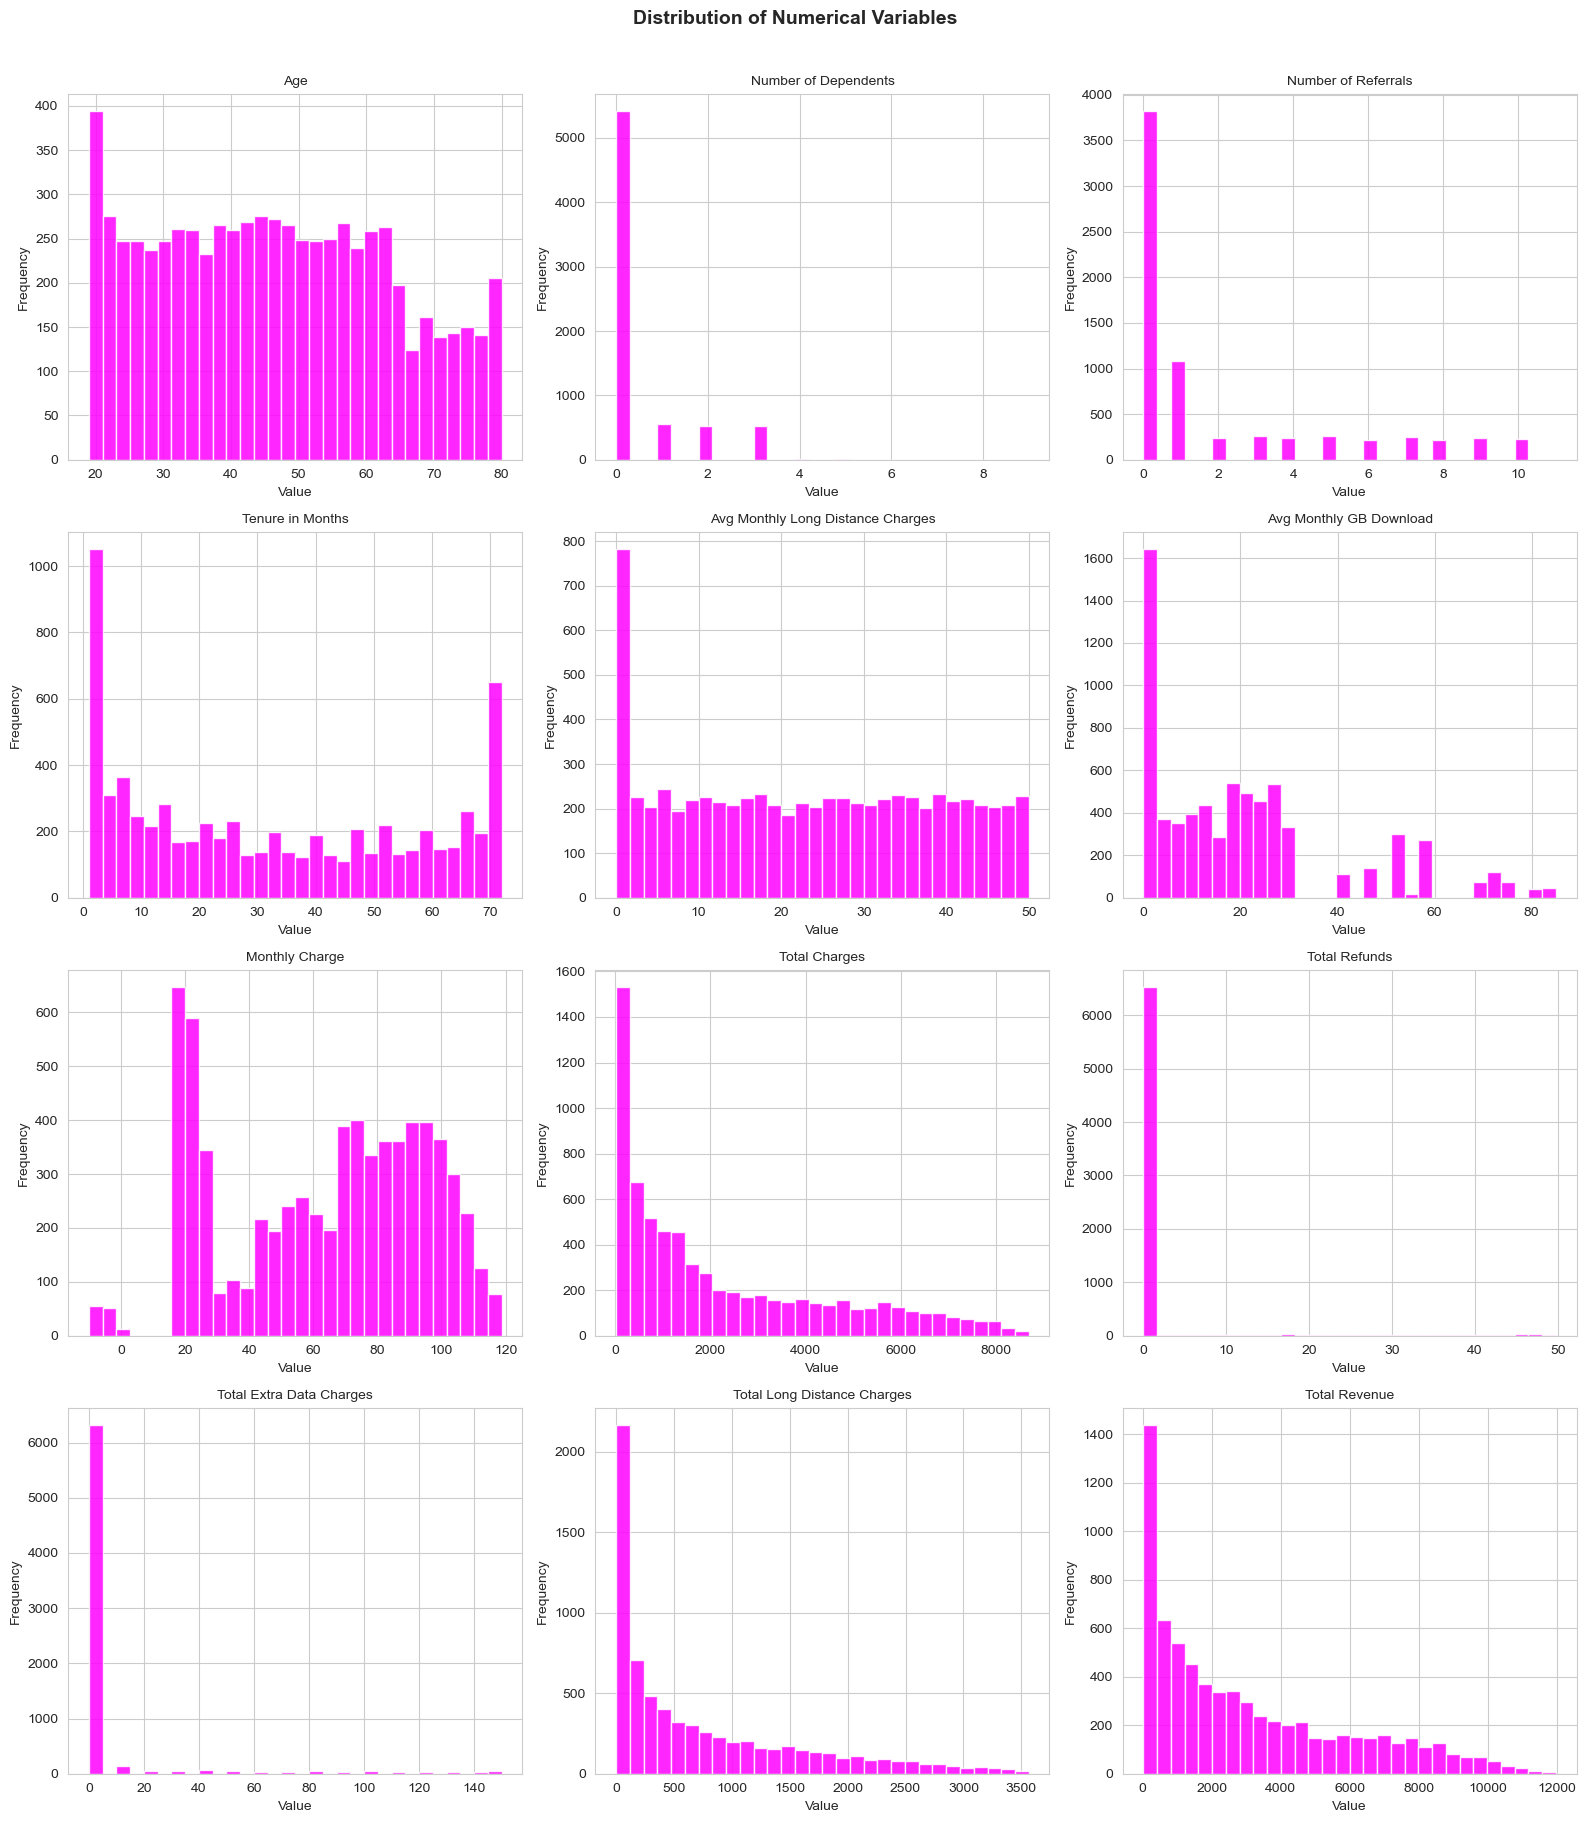

In [56]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='magenta', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Numerical Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

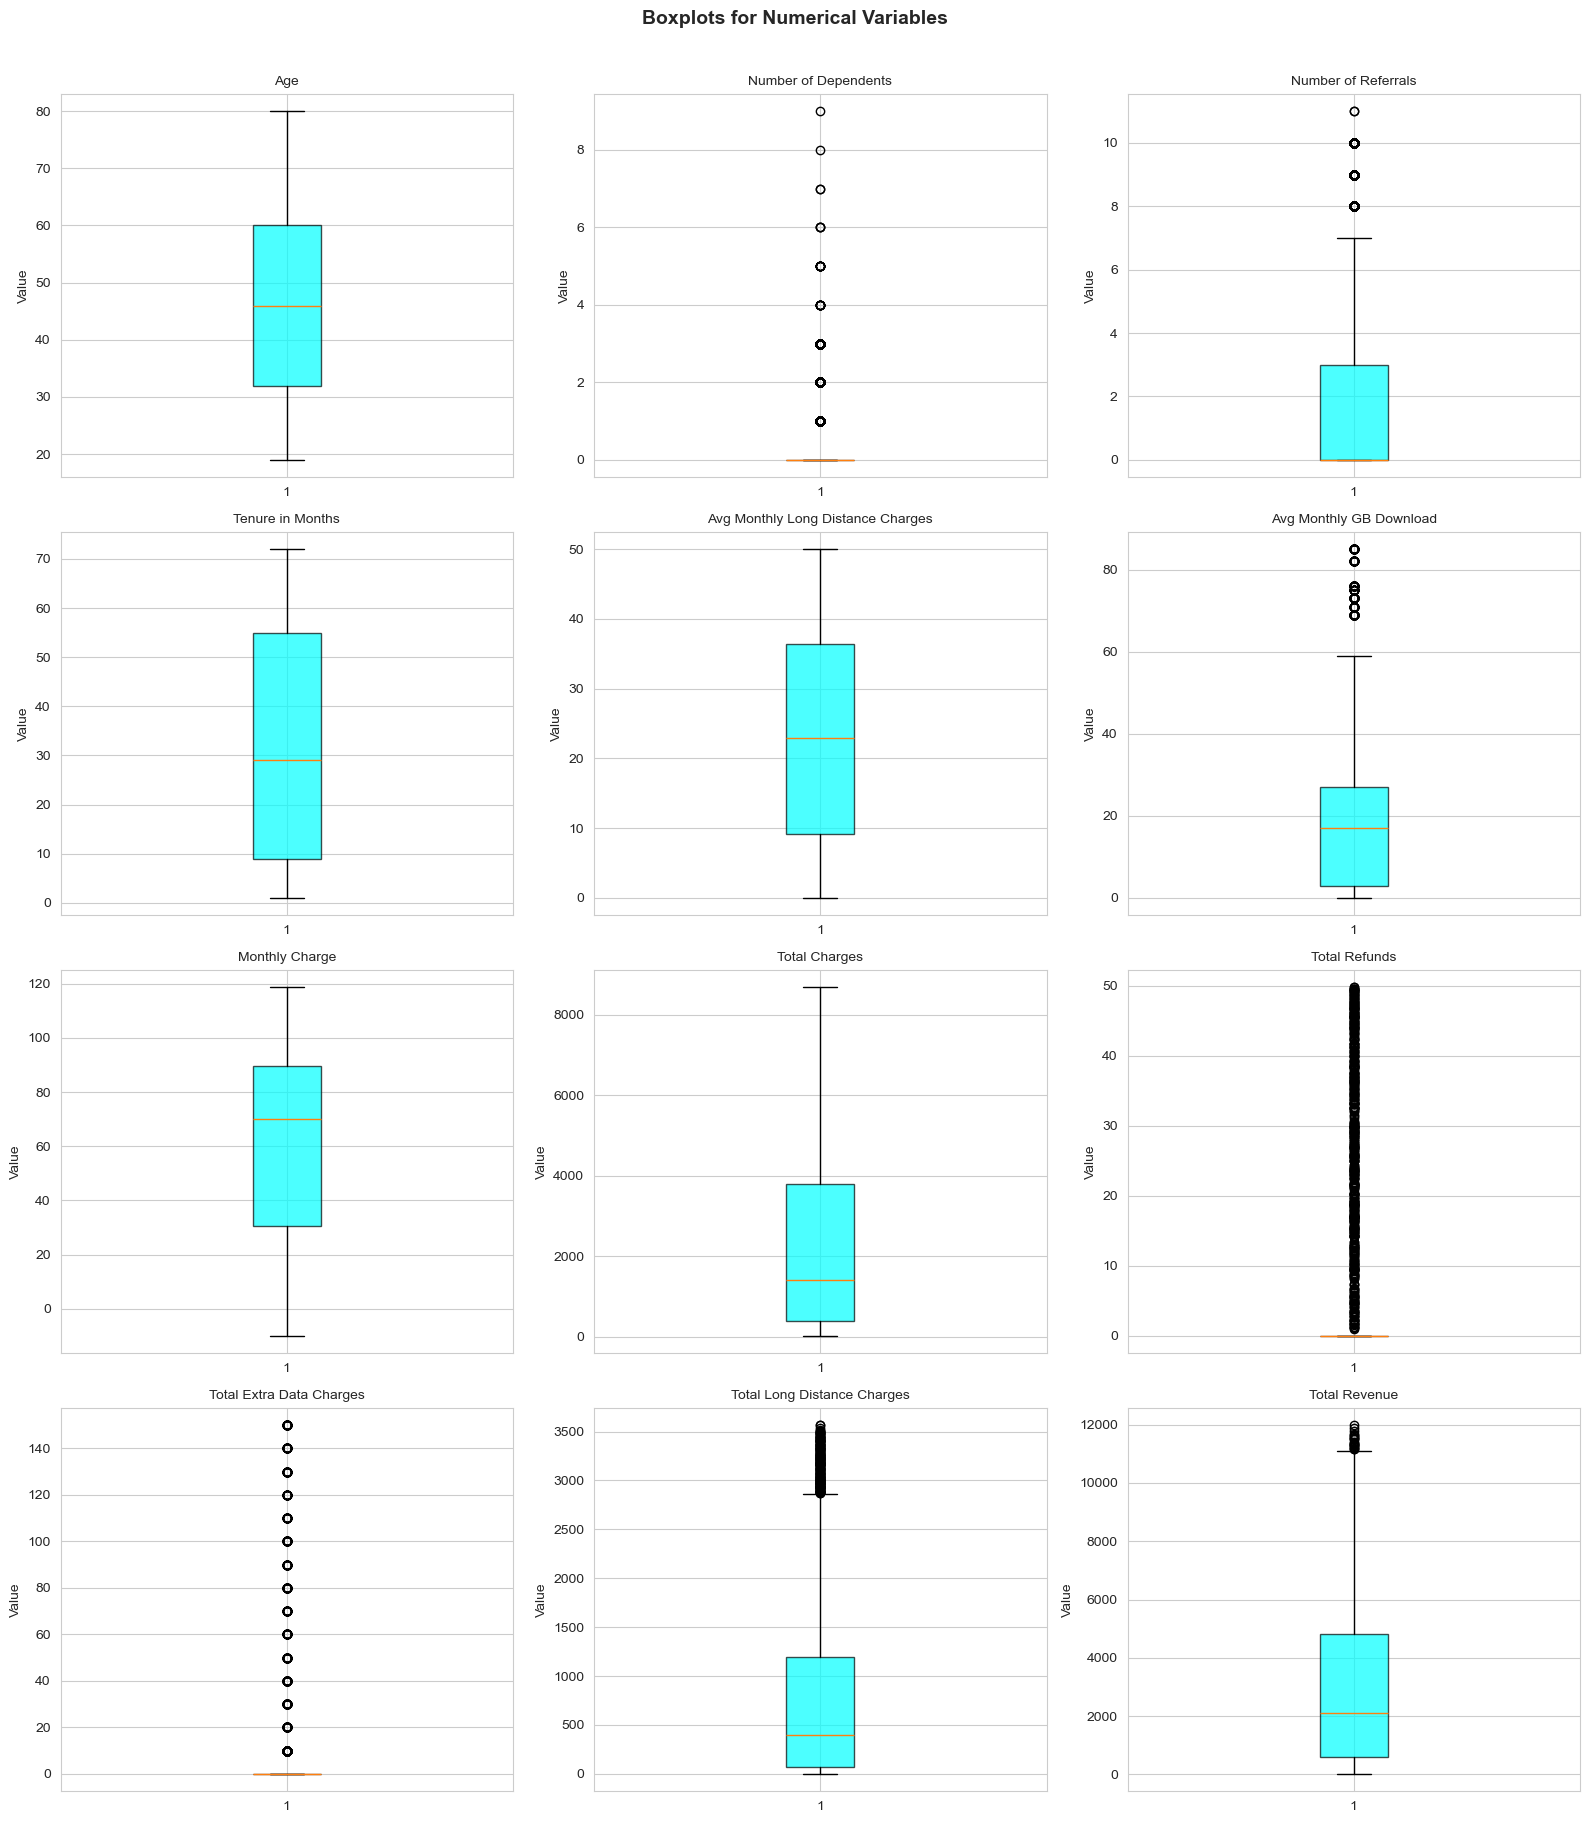

In [57]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='cyan', alpha=0.7))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots for Numerical Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Numerical Variables by Customer Status

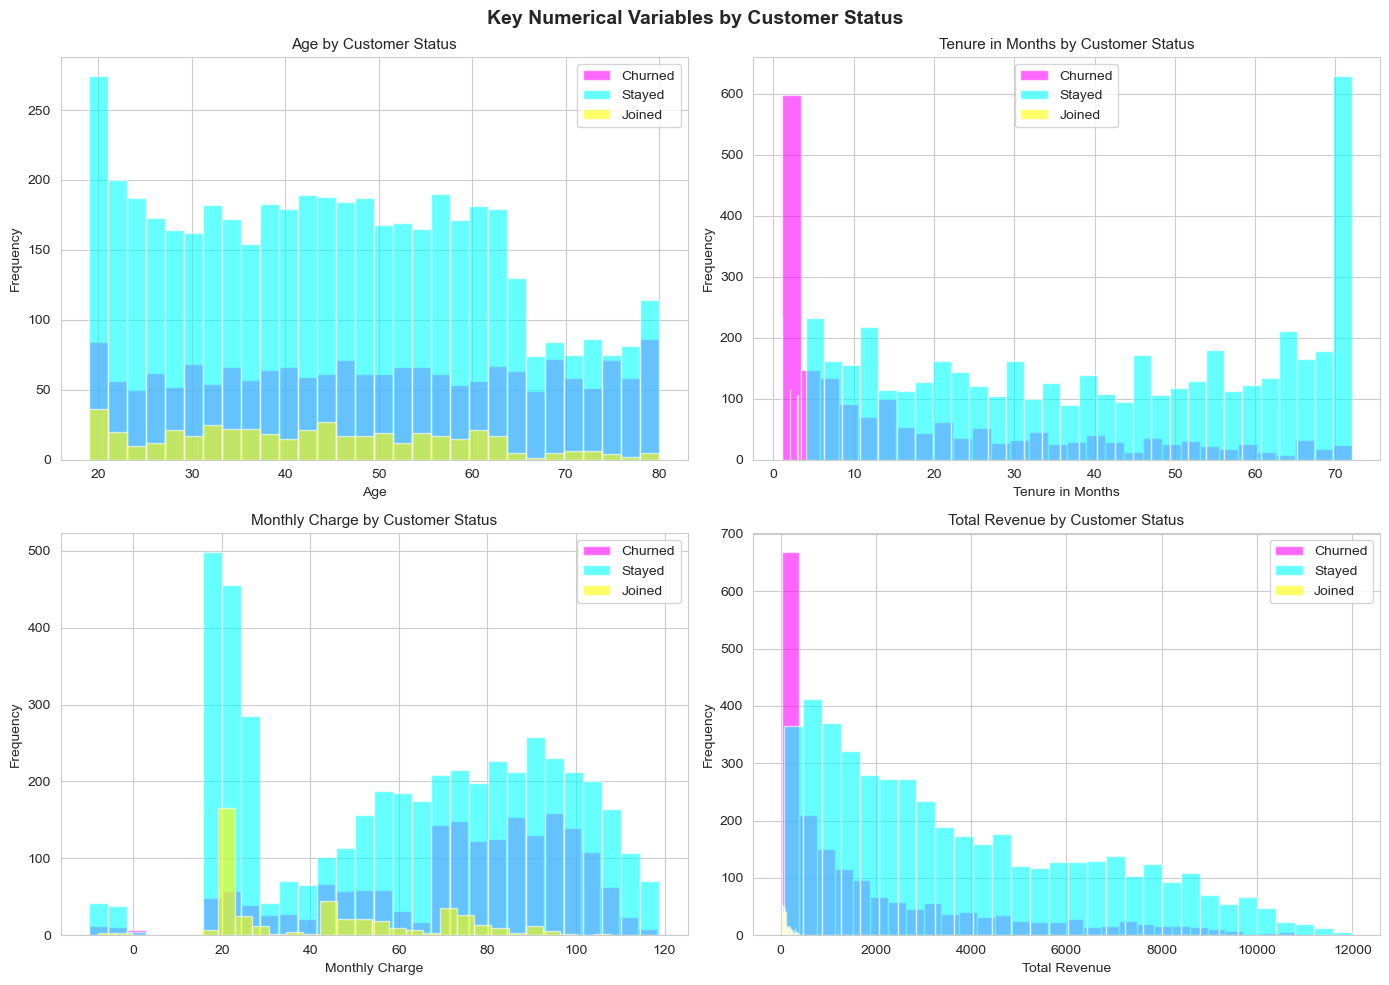

In [58]:
key_numerics = ['Age', 'Tenure in Months', 'Monthly Charge', 'Total Revenue']
status_palette = {'Churned': "#FF00ff", 'Stayed': "#00ffFF", 'Joined': "#ffff00"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_numerics):
    for status, color in status_palette.items():
        subset = df[df['Customer Status'] == status][col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=status, color=color, edgecolor='white')
    axes[i].set_title(f'{col} by Customer Status', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Key Numerical Variables by Customer Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [59]:
print("Mean values by Customer Status:")
print(df.groupby('Customer Status')[key_numerics].mean().round(2))

Mean values by Customer Status:
                   Age  Tenure in Months  Monthly Charge  Total Revenue
Customer Status                                                        
Churned          49.74             17.98           73.35        1971.35
Joined           42.87              1.72           42.78         119.56
Stayed           45.58             41.04           61.74        3735.68


### 5.4 Categorical Variable Analysis

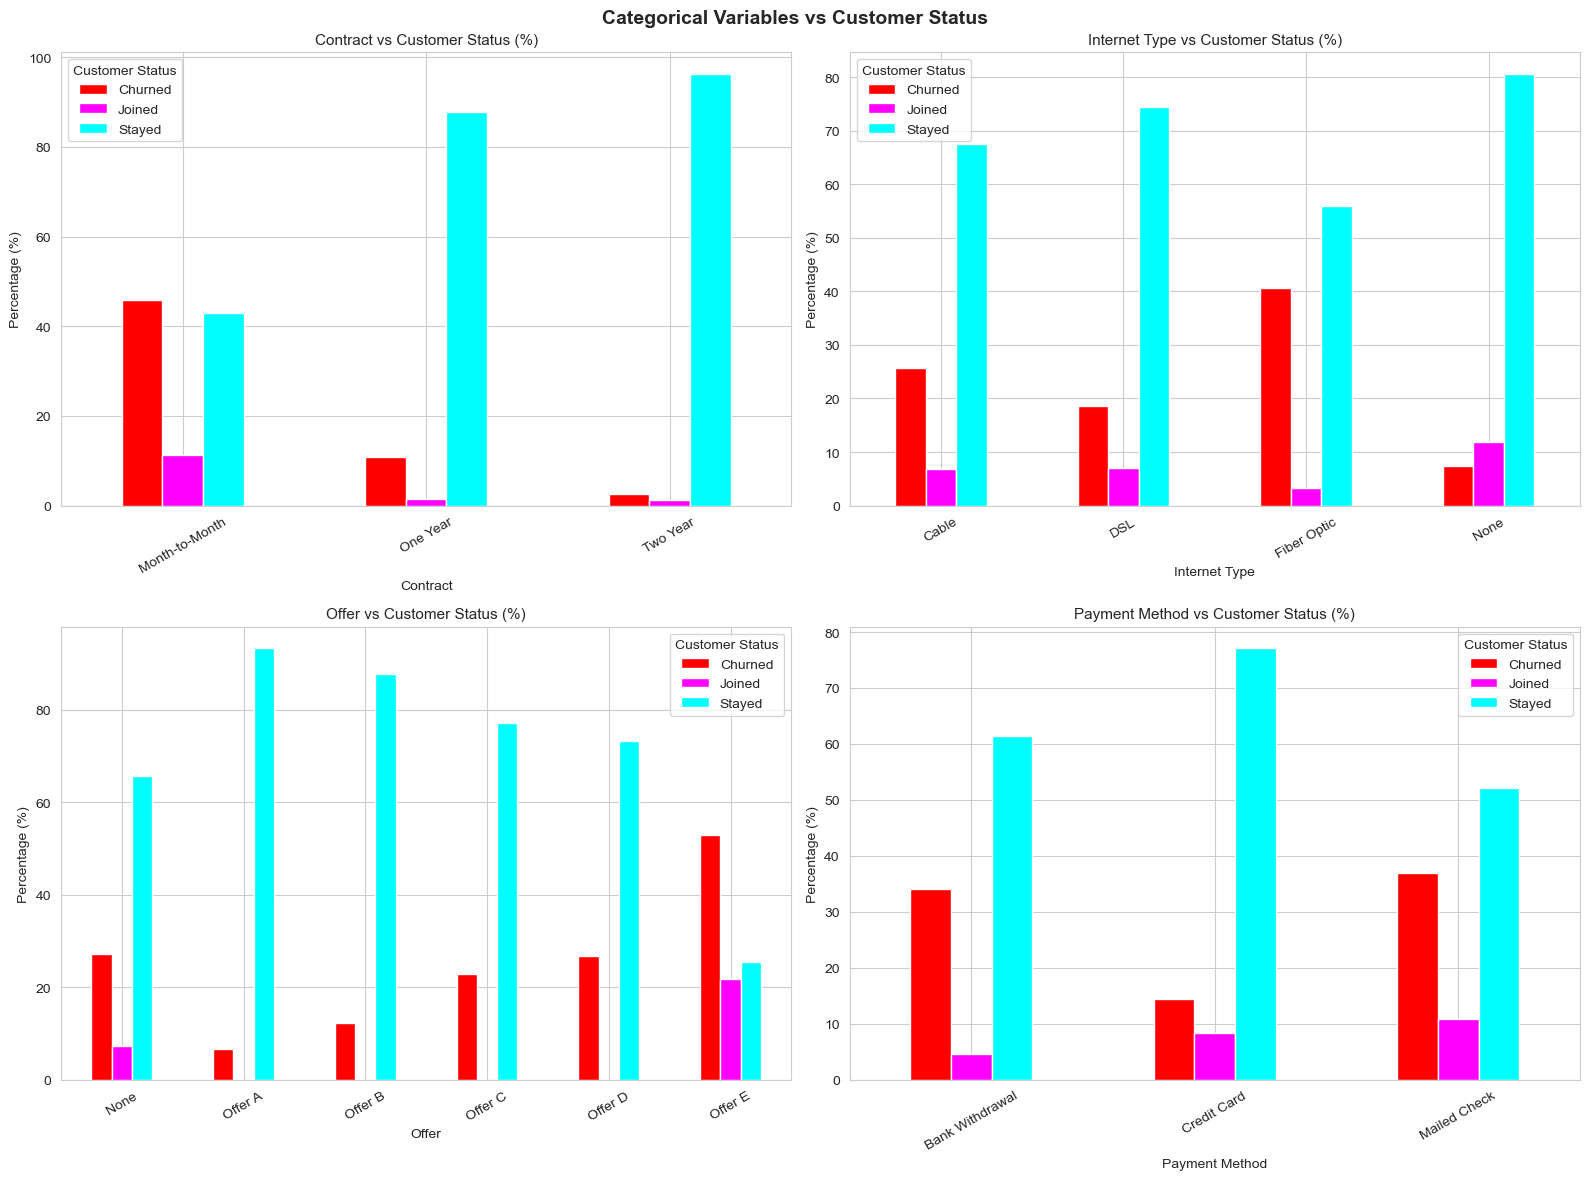

In [60]:
cat_cols = ['Contract', 'Internet Type', 'Offer', 'Payment Method']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Customer Status'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color = [ '#ff0000',"#FF00FF", "#00ffff"], edgecolor='white')
    axes[i].set_title(f'{col} vs Customer Status (%)', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Customer Status')

plt.suptitle('Categorical Variables vs Customer Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

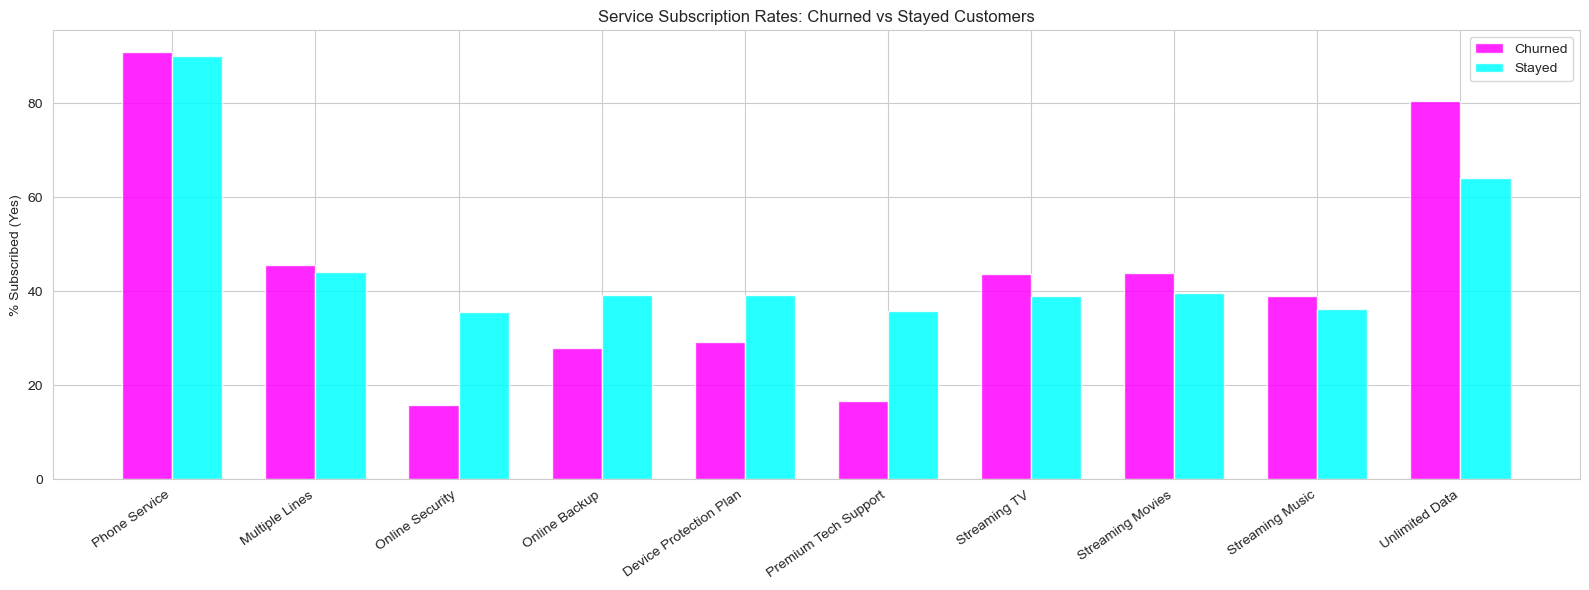

In [61]:
service_cols = [
    'Phone Service', 'Multiple Lines', 'Online Security', 'Online Backup',
    'Device Protection Plan', 'Premium Tech Support',
    'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data'
]

churned_df = df[df['Customer Status'] == 'Churned']
stayed_df = df[df['Customer Status'] == 'Stayed']

churn_yes_pct = [(churned_df[col] == 'Yes').mean() * 100 for col in service_cols]
stayed_yes_pct = [(stayed_df[col] == 'Yes').mean() * 100 for col in service_cols]

x = np.arange(len(service_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width/2, churn_yes_pct, width, label='Churned', color='#FF00FF', alpha=0.85)
ax.bar(x + width/2, stayed_yes_pct, width, label='Stayed', color='#00ffff', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(service_cols, rotation=35, ha='right')
ax.set_ylabel('% Subscribed (Yes)')
ax.set_title('Service Subscription Rates: Churned vs Stayed Customers')
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Churn Reason Analysis

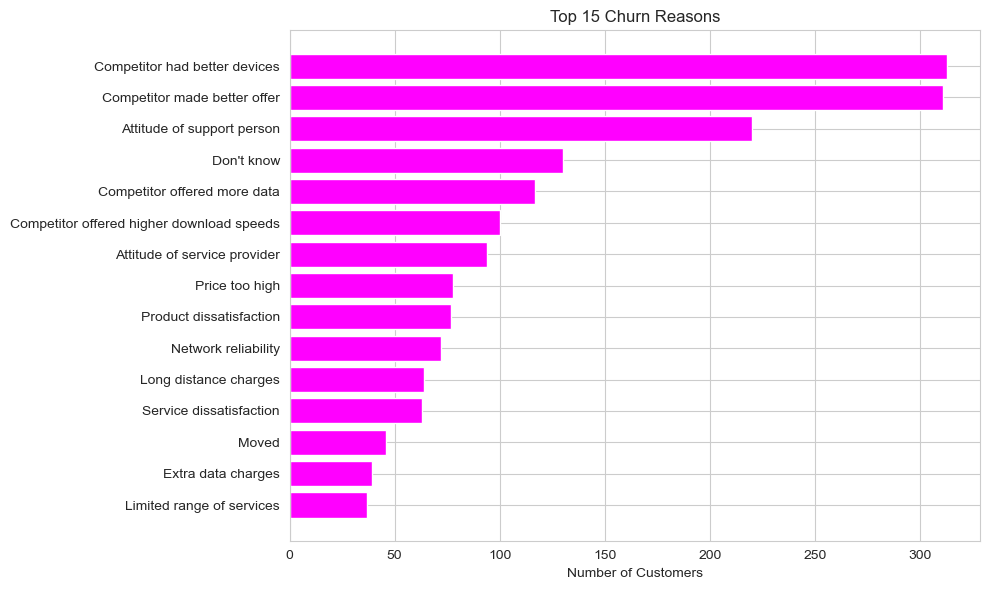

In [62]:
churn_reasons = churned_df['Churn Reason'].value_counts().head(15)

plt.figure(figsize=(10, 6))
plt.barh(churn_reasons.index[::-1], churn_reasons.values[::-1],
         color='#ff00ff', edgecolor='white')
plt.xlabel('Number of Customers')
plt.title('Top 15 Churn Reasons')
plt.tight_layout()
plt.show()

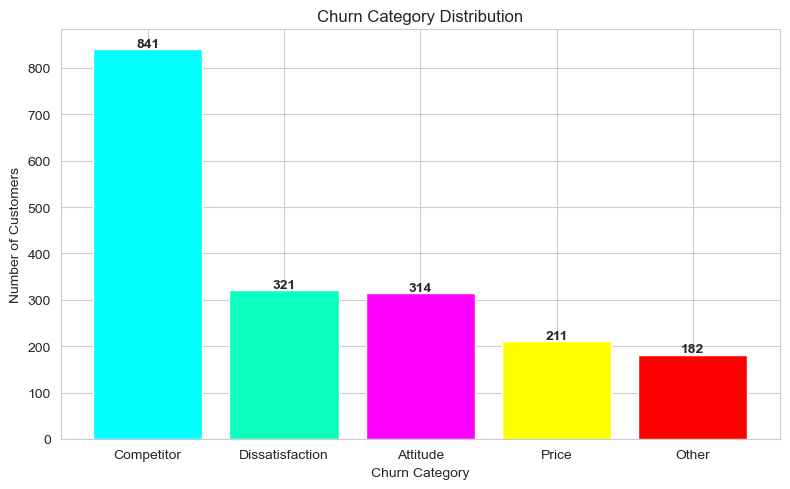

In [63]:
churn_cat_counts = churned_df['Churn Category'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(churn_cat_counts.index, churn_cat_counts.values,
        color=['#00FFFF', "#0BFFBE", '#FF00FF', "#ffff00", '#FF0000', ],
        edgecolor='white')
plt.xlabel('Churn Category')
plt.ylabel('Number of Customers')
plt.title('Churn Category Distribution')
for i, v in enumerate(churn_cat_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 5.6 Correlation Heatmap (Numerical Variables)

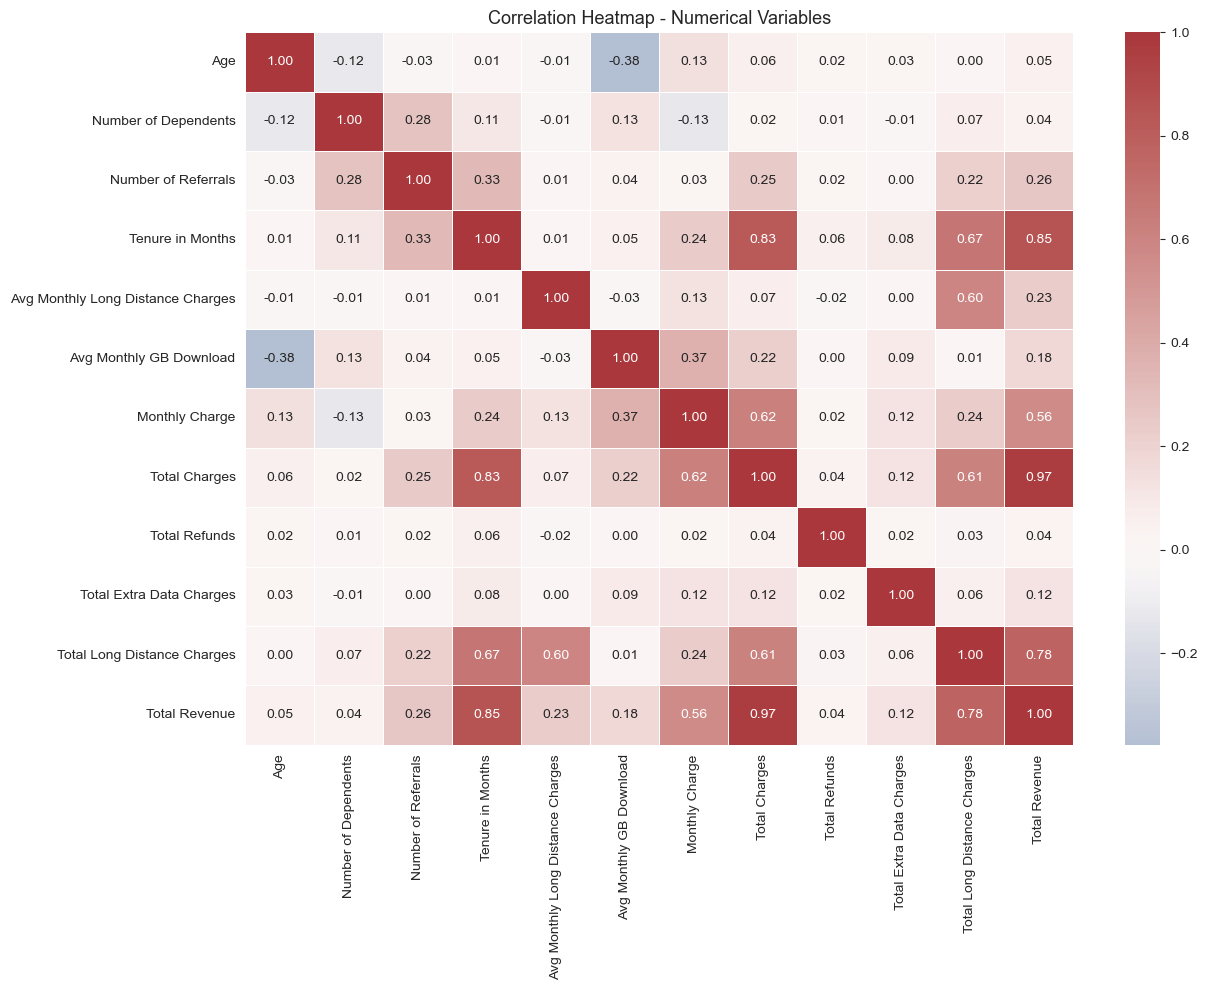

In [64]:
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='vlag',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap - Numerical Variables', fontsize=13)
plt.tight_layout()
plt.show()

## Step 6: Statistical Tests

### T-Test and ANOVA

The selected numerical variables and groupings for hypothesis testing are:
- **Monthly Charge vs Churn Status (Churned vs Stayed):** Do churned customers pay significantly higher monthly charges?
- **Tenure in Months vs Churn Status (Churned vs Stayed):** Do churned customers have shorter tenures?
- **Monthly Charge across Contract Types:** Does contract type significantly affect monthly charges?
- **Total Revenue across Internet Types:** Does the type of internet connection significantly affect total revenue generated?

| Test | Variable | Grouping | H0 | Result |
|------|----------|----------|---------|-------|
| T-Test | Monthly Charge | Churned vs Stayed | No difference in mean Monthly Charge | Reject H0 |
| T-Test | Tenure in Months | Churned vs Stayed | No difference in mean Tenure | Reject H0 | 
| ANOVA | Monthly Charge | Contract Type | All contracts have equal mean Monthly Charge | Reject H0 |
| ANOVA | Total Revenue | Internet Type | All internet types produce equal mean Total Revenue | Reject H0 |

In [65]:
from scipy.stats import ttest_ind, f_oneway

churned_vals = df[df['Customer Status'] == 'Churned']
stayed_vals = df[df['Customer Status'] == 'Stayed']

t_stat, p_val = ttest_ind(
    churned_vals['Monthly Charge'],
    stayed_vals['Monthly Charge']
)
print(f"T-Test: Monthly Charge (Churned vs Stayed)")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value: {p_val:.6f}")
print(f"  Decision: {'Reject H0' if p_val < 0.05 else 'Fail to Reject H0'}\n")

t_stat2, p_val2 = ttest_ind(
    churned_vals['Tenure in Months'],
    stayed_vals['Tenure in Months']
)
print(f"T-Test: Tenure in Months (Churned vs Stayed)")
print(f"  T-statistic: {t_stat2:.4f}")
print(f"  P-value: {p_val2:.6f}")
print(f"  Decision: {'Reject H0' if p_val2 < 0.05 else 'Fail to Reject H0'}")

T-Test: Monthly Charge (Churned vs Stayed)
  T-statistic: 13.8561
  P-value: 0.000000
  Decision: Reject H0

T-Test: Tenure in Months (Churned vs Stayed)
  T-statistic: -39.0709
  P-value: 0.000000
  Decision: Reject H0


In [66]:
contract_groups = [group['Monthly Charge'].values
                   for _, group in df.groupby('Contract')]

f_stat, p_val3 = f_oneway(*contract_groups)
print(f"ANOVA: Monthly Charge across Contract Types")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  P-value: {p_val3:.6f}")
print(f"  Decision: {'Reject H0' if p_val3 < 0.05 else 'Fail to Reject H0'}\n")

internet_groups = [group['Total Revenue'].values
                   for _, group in df.groupby('Internet Type')]

f_stat2, p_val4 = f_oneway(*internet_groups)
print(f"ANOVA: Total Revenue across Internet Types")
print(f"  F-statistic: {f_stat2:.4f}")
print(f"  P-value: {p_val4:.6f}")
print(f"  Decision: {'Reject H0' if p_val4 < 0.05 else 'Fail to Reject H0'}")

ANOVA: Monthly Charge across Contract Types
  F-statistic: 6.3302
  P-value: 0.001792
  Decision: Reject H0

ANOVA: Total Revenue across Internet Types
  F-statistic: 350.8873
  P-value: 0.000000
  Decision: Reject H0


### Tukey Test

Applied when ANOVA rejects H0, to identify which specific group pairs differ significantly.

In [67]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

if p_val3 < 0.05:
    tukey_contract = pairwise_tukeyhsd(
        endog=df['Monthly Charge'],
        groups=df['Contract'],
        alpha=0.05
    )
    print("Tukey HSD: Monthly Charge across Contract Types")
    print(tukey_contract)

Tukey HSD: Monthly Charge across Contract Types
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1      group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
Month-to-Month One Year   0.0115 0.9999 -2.2082  2.2312  False
Month-to-Month Two Year  -2.9836 0.0022 -5.0614 -0.9057   True
      One Year Two Year  -2.9951 0.0142  -5.502 -0.4882   True
--------------------------------------------------------------


In [68]:
if p_val4 < 0.05:
    tukey_internet = pairwise_tukeyhsd(
        endog=df['Total Revenue'],
        groups=df['Internet Type'],
        alpha=0.05
    )
    print("Tukey HSD: Total Revenue across Internet Types")
    print(tukey_internet)

Tukey HSD: Total Revenue across Internet Types
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
   group1      group2    meandiff  p-adj    lower      upper    reject
----------------------------------------------------------------------
      Cable         DSL    68.8985 0.9303  -223.3248   361.1218  False
      Cable Fiber Optic  1403.4189    0.0  1134.3805  1672.4574   True
      Cable        None -1252.8684    0.0 -1549.0986  -956.6382   True
        DSL Fiber Optic  1334.5204    0.0  1124.5196  1544.5213   True
        DSL        None -1321.7669    0.0 -1565.6337 -1077.9002   True
Fiber Optic        None -2656.2874    0.0 -2871.8291 -2440.7456   True
----------------------------------------------------------------------


### Chi-Square Test

The selected variables for Chi-Square Test are:
- **Contract vs Customer Status:** Are customers on month-to-month contracts more likely to churn?
- **Internet Type vs Customer Status:** Is there a relationship between internet connection type and churn?
- **Offer vs Customer Status:** Do specific marketing offers affect whether a customer churns?
- **Payment Method vs Customer Status:** Is payment method associated with churn behavior?
- **Gender vs Customer Status:** Does gender influence churn likelihood?
- **Married vs Customer Status:** Are married customers less likely to churn?
- **Paperless Billing vs Customer Status:** Does opting into paperless billing relate to churn?

| Variable Pair | Decision | Interpretation |
|--------------|--------|----------|
| Contract vs Customer Status | Reject H0 | Contract type strongly associated with churn |
| Internet Type vs Customer Status | Reject H0 | Internet type strongly associated with churn |
| Offer vs Customer Status | Reject H0 | Offers strongly associated with churn | 
| Payment Method vs Customer Status | Reject H0 | Payment method associated with churn | 
| Gender vs Customer Status | Fail to reject H0 | No significant association | 
| Married vs Customer Status | Reject H0 | Marital status associated with churn | 
| Paperless Billing vs Customer Status | Reject H0 | Paperless billing associated with churn |

In [69]:
from scipy.stats import chi2_contingency

cat_pairs = [
    ('Contract', 'Customer Status'),
    ('Internet Type', 'Customer Status'),
    ('Offer', 'Customer Status'),
    ('Payment Method', 'Customer Status'),
    ('Gender', 'Customer Status'),
    ('Married', 'Customer Status'),
    ('Paperless Billing', 'Customer Status')
]

for col1, col2 in cat_pairs:
    table = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(table)
    decision = 'Reject H0' if p < 0.05 else 'Fail to Reject H0'
    print(f"Chi-Square: {col1} vs {col2}")
    print(f"  Chi-square statistic: {chi2:.4f}")
    print(f"  P-value: {p:.6f}")
    print(f"  Decision: {decision}\n")

Chi-Square: Contract vs Customer Status
  Chi-square statistic: 1987.3647
  P-value: 0.000000
  Decision: Reject H0

Chi-Square: Internet Type vs Customer Status
  Chi-square statistic: 709.6153
  P-value: 0.000000
  Decision: Reject H0

Chi-Square: Offer vs Customer Status
  Chi-square statistic: 1127.2667
  P-value: 0.000000
  Decision: Reject H0

Chi-Square: Payment Method vs Customer Status
  Chi-square statistic: 369.4542
  P-value: 0.000000
  Decision: Reject H0

Chi-Square: Gender vs Customer Status
  Chi-square statistic: 2.0718
  P-value: 0.354901
  Decision: Fail to Reject H0

Chi-Square: Married vs Customer Status
  Chi-square statistic: 394.1534
  P-value: 0.000000
  Decision: Reject H0

Chi-Square: Paperless Billing vs Customer Status
  Chi-square statistic: 280.4509
  P-value: 0.000000
  Decision: Reject H0



### Results Summary

**T-Tests:**
- Monthly Charge differs significantly between churned and stayed customers, indicating that churned customers tend to have higher monthly bills, suggesting price sensitivity is a churn driver.
- Tenure in Months also differs significantly, with churned customers having shorter tenure on average, confirming that early-stage customers are more at risk of leaving.

**ANOVA + Tukey:**
- Monthly Charge differs significantly across contract types. Tukey test reveals that Month-to-Month and One Year contracts have nearly identical pricing, while Two Year contract customers pay ~$3/month less on average.
- Total Revenue differs significantly across internet types, with Fiber Optic customers generating the highest revenue, Cable and DSL in the middle, and no internet generating the lowest revenue.

**Chi-Square:**
- Contract type, Internet Type, Payment Method, Married, and Paperless Billing and Offer all show statistically significant associations with Customer Status, confirming these are meaningful predictors of churn behavior.
- Gender does not show a significant association with churn.

In [70]:
df.to_csv('telecom_customer_churn_clean.csv', index=False)
print("Clean dataset saved as telecom_customer_churn_clean.csv")

Clean dataset saved as telecom_customer_churn_clean.csv
